In [8]:
import os
import copy
import glob
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import imageio
from tqdm import tqdm
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


'expandable_segments:True'

In [9]:
# Config: paths and hyperparameters
import os
from dataclasses import dataclass

# Set your dataset root that contains: rgb/, depth/, mask/ (256x256 each)
DATASET_ROOT = "/home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/"
RGB_DIR = "rgb-imgs"
DEPTH_DIR = "depth-imgs-rectified"
MASK_DIR = "segmentation-masks"

# Depth range in meters for normalization to [-1,1]
DEPTH_MINMAX = (0.0, 5.0)

# Noise parameters (normalized depth space [-1,1])
SIGMA_MASK = 0.08     # heavy noise on transparent regions
SIGMA_GLOBAL = 0.01   # light noise everywhere

# Training
BATCH_SIZE = 16  # lowered to fit 8GB VRAM at 128x128
LR = 1e-4
EPOCHS = 20            # increase for real training
TIMESTEPS = 1000
NUM_WORKERS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True if DEVICE == "cuda" else False


In [10]:
# Imports and dataset/dataloaders
import torch
from torch.utils.data import DataLoader
from diffusion import GaussianDiffusion, DiffusionConfig
from conditional_unet_depth import ConditionalUNetDepth
from data_pipeline import DepthInpaintDataset, DepthDataConfig
from guidance_maps import GuidanceConfig

# Prepare datasets for optical and geometric branches
gcfg = GuidanceConfig()
IMG_SIZE = (128, 128)  # lowered resolution to fit 8GB VRAM
cfg_opt = DepthDataConfig(
    root=DATASET_ROOT, rgb_dir=RGB_DIR, depth_dir=DEPTH_DIR, mask_dir=MASK_DIR,
    size=IMG_SIZE, depth_minmax=DEPTH_MINMAX,
    sigma_mask=SIGMA_MASK, sigma_global=SIGMA_GLOBAL,
    branch="optical", include_guidance=True,
 )
cfg_geo = DepthDataConfig(
    root=DATASET_ROOT, rgb_dir=RGB_DIR, depth_dir=DEPTH_DIR, mask_dir=MASK_DIR,
    size=IMG_SIZE, depth_minmax=DEPTH_MINMAX,
    sigma_mask=SIGMA_MASK, sigma_global=SIGMA_GLOBAL,
    branch="geometric", include_guidance=True,
 )

ds_opt = DepthInpaintDataset(cfg_opt, gcfg)
ds_geo = DepthInpaintDataset(cfg_geo, gcfg)

dl_opt = DataLoader(ds_opt, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
dl_geo = DataLoader(ds_geo, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)


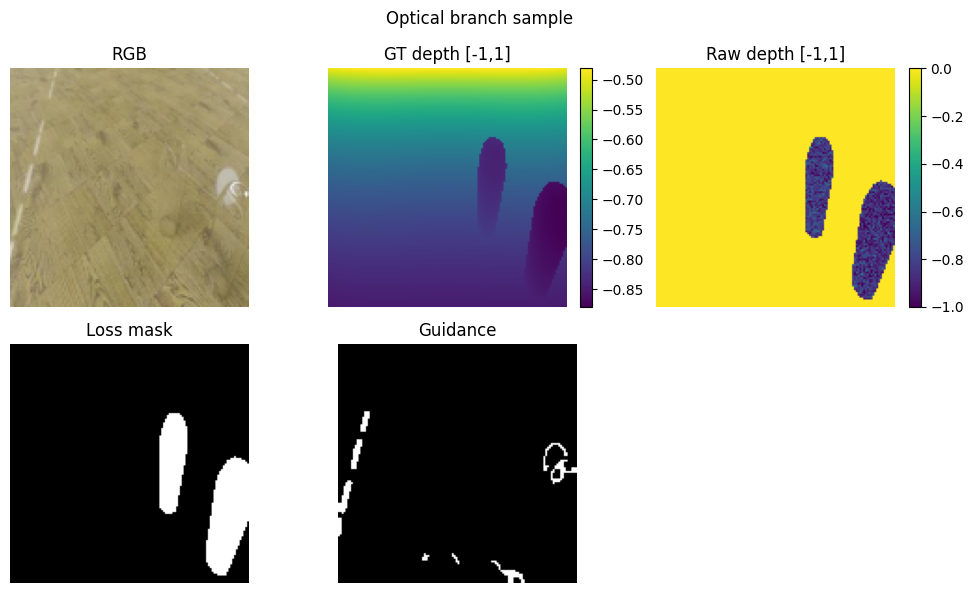

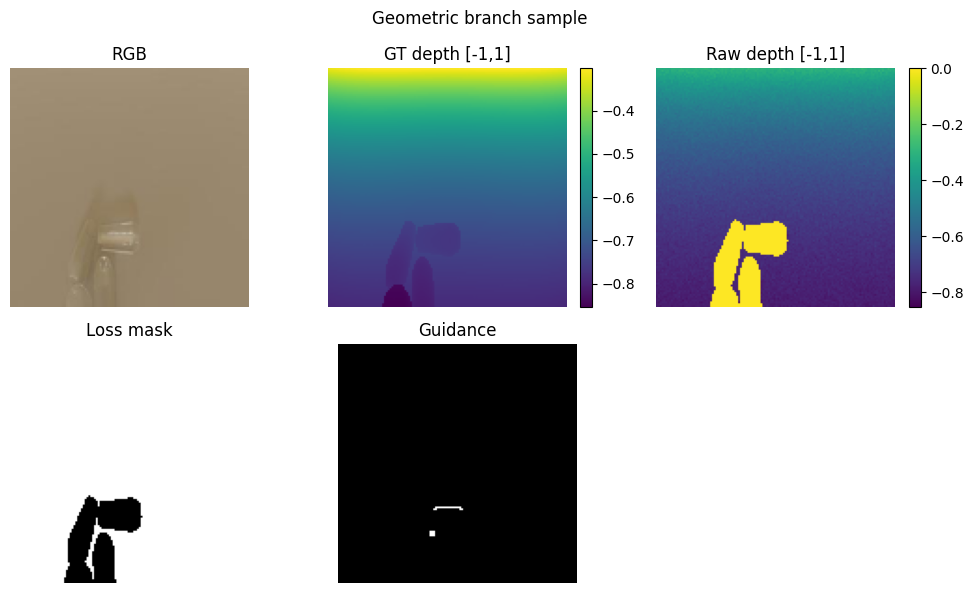

In [11]:
# Visualize a sample from each branch
import matplotlib.pyplot as plt
import numpy as np
import cv2

def viz_sample(batch, title_prefix=""):
    depth = batch["pixel_values"][0].cpu().numpy()[0]  # [-1,1]
    cond = batch["conditioning"][0].cpu().numpy()
    loss_mask = batch["loss_mask"][0].cpu().numpy()[0]
    # cond layout: [RGB(3), raw(1), guide(1)]
    rgb = cond[:3]
    raw = cond[3]
    guide = cond[4]
    rgb_viz = (np.clip(rgb.transpose(1,2,0), 0, 1) * 255).astype(np.uint8)
    rgb_viz = cv2.cvtColor(rgb_viz, cv2.COLOR_RGB2BGR)
    plt.figure(figsize=(10,6))
    plt.suptitle(title_prefix)
    plt.subplot(2,3,1); plt.title("RGB"); plt.imshow(cv2.cvtColor(rgb_viz, cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.subplot(2,3,2); plt.title("GT depth [-1,1]"); plt.imshow(depth, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(2,3,3); plt.title("Raw depth [-1,1]"); plt.imshow(raw, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(2,3,4); plt.title("Loss mask"); plt.imshow(loss_mask, cmap='gray'); plt.axis('off')
    plt.subplot(2,3,5); plt.title("Guidance"); plt.imshow(guide, cmap='gray'); plt.axis('off')
    plt.tight_layout(); plt.show()

opt_batch = next(iter(dl_opt))
geo_batch = next(iter(dl_geo))
viz_sample(opt_batch, title_prefix="Optical branch sample")
viz_sample(geo_batch, title_prefix="Geometric branch sample")

In [12]:
# Training utility for a branch
def train_branch(branch_name: str, dataloader, save_path: str):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalUNetDepth(cond_channels=5).to(device)
    diffusion = GaussianDiffusion(model=model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))
    model.train()
    diffusion.train()
    step = 0
    for epoch in range(EPOCHS):
        epoch_bar = tqdm(dataloader, desc=f"[{branch_name}] Epoch {epoch+1}/{EPOCHS}", leave=False)
        for batch in epoch_bar:
            x0 = batch["pixel_values"].to(device, non_blocking=True)
            cond = batch["conditioning"].to(device, non_blocking=True)
            mask = batch.get("loss_mask", None)
            if mask is not None:
                mask = mask.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                loss = diffusion.p_losses({
                    "pixel_values": x0,
                    "conditioning": cond,
                    "loss_mask": mask,
                })
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            if step % 50 == 0:
                print(f"[{branch_name}] step {step} loss {loss.item():.4f} on {device}")
            step += 1
    # save UNet weights (the diffusion wrapper has buffers, we'll save model only)
    torch.save(model.state_dict(), save_path)
    return model, diffusion

In [13]:
# Run short training for optical and geometric branches (saving checkpoints in CWD)
import os, torch
CHECKPOINT_DIR = os.getcwd()
opt_model_path = os.path.join(CHECKPOINT_DIR, "model_optical.pt")
geo_model_path = os.path.join(CHECKPOINT_DIR, "model_geometric.pt")
print(f"Saving checkpoints to: {CHECKPOINT_DIR}")
opt_model, opt_diff = train_branch("optical", dl_opt, opt_model_path)
del opt_model, opt_diff
torch.cuda.empty_cache()
geo_model, geo_diff = train_branch("geometric", dl_geo, geo_model_path)

Saving checkpoints to: /home/cago/MMI_714_generative_models/term_project/src


[optical] Epoch 1/20:   0%|          | 1/2841 [00:38<30:15:23, 38.35s/it]

[optical] step 0 loss 1.3230 on cuda


[optical] Epoch 1/20:   2%|▏         | 51/2841 [00:55<16:29,  2.82it/s]  

[optical] step 50 loss 0.0209 on cuda


[optical] Epoch 1/20:   4%|▎         | 101/2841 [01:13<16:12,  2.82it/s]

[optical] step 100 loss 0.0111 on cuda


[optical] Epoch 1/20:   5%|▌         | 151/2841 [01:31<16:06,  2.78it/s]

[optical] step 150 loss 0.0280 on cuda


KeyboardInterrupt: 

In [6]:
# Load trained models for inference (since training deletes them to save VRAM)
import os
device = torch.device(DEVICE)

# Reload optical model
opt_model = ConditionalUNetDepth(cond_channels=5).to(device)
opt_model.load_state_dict(torch.load(os.path.join(os.getcwd(), "model_optical.pt"), map_location=device, weights_only=True))
opt_diff = GaussianDiffusion(model=opt_model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)

# Reload geometric model
geo_model = ConditionalUNetDepth(cond_channels=5).to(device)
geo_model.load_state_dict(torch.load(os.path.join(os.getcwd(), "model_geometric.pt"), map_location=device, weights_only=True))
geo_diff = GaussianDiffusion(model=geo_model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)

print("Models loaded for inference.")

# IMPORTANT: Get the SAME sample for both branches
# We'll use the optical dataset and manually compute the geometric mask/guidance
sample_idx = 0
sample = ds_opt[sample_idx]

# Create batch with single sample
batch_shared = {
    "pixel_values": sample["pixel_values"].unsqueeze(0),
    "conditioning": sample["conditioning"].unsqueeze(0),
    "loss_mask": sample["loss_mask"].unsqueeze(0),  # This is the optical mask (1=glass)
}

print(f"Using sample index {sample_idx} for both branches")

Models loaded for inference.
Using sample index 0 for both branches


Running Optical Branch (unconstrained sampling)...
Running Geometric Branch (unconstrained sampling)...
Running Geometric Branch (unconstrained sampling)...


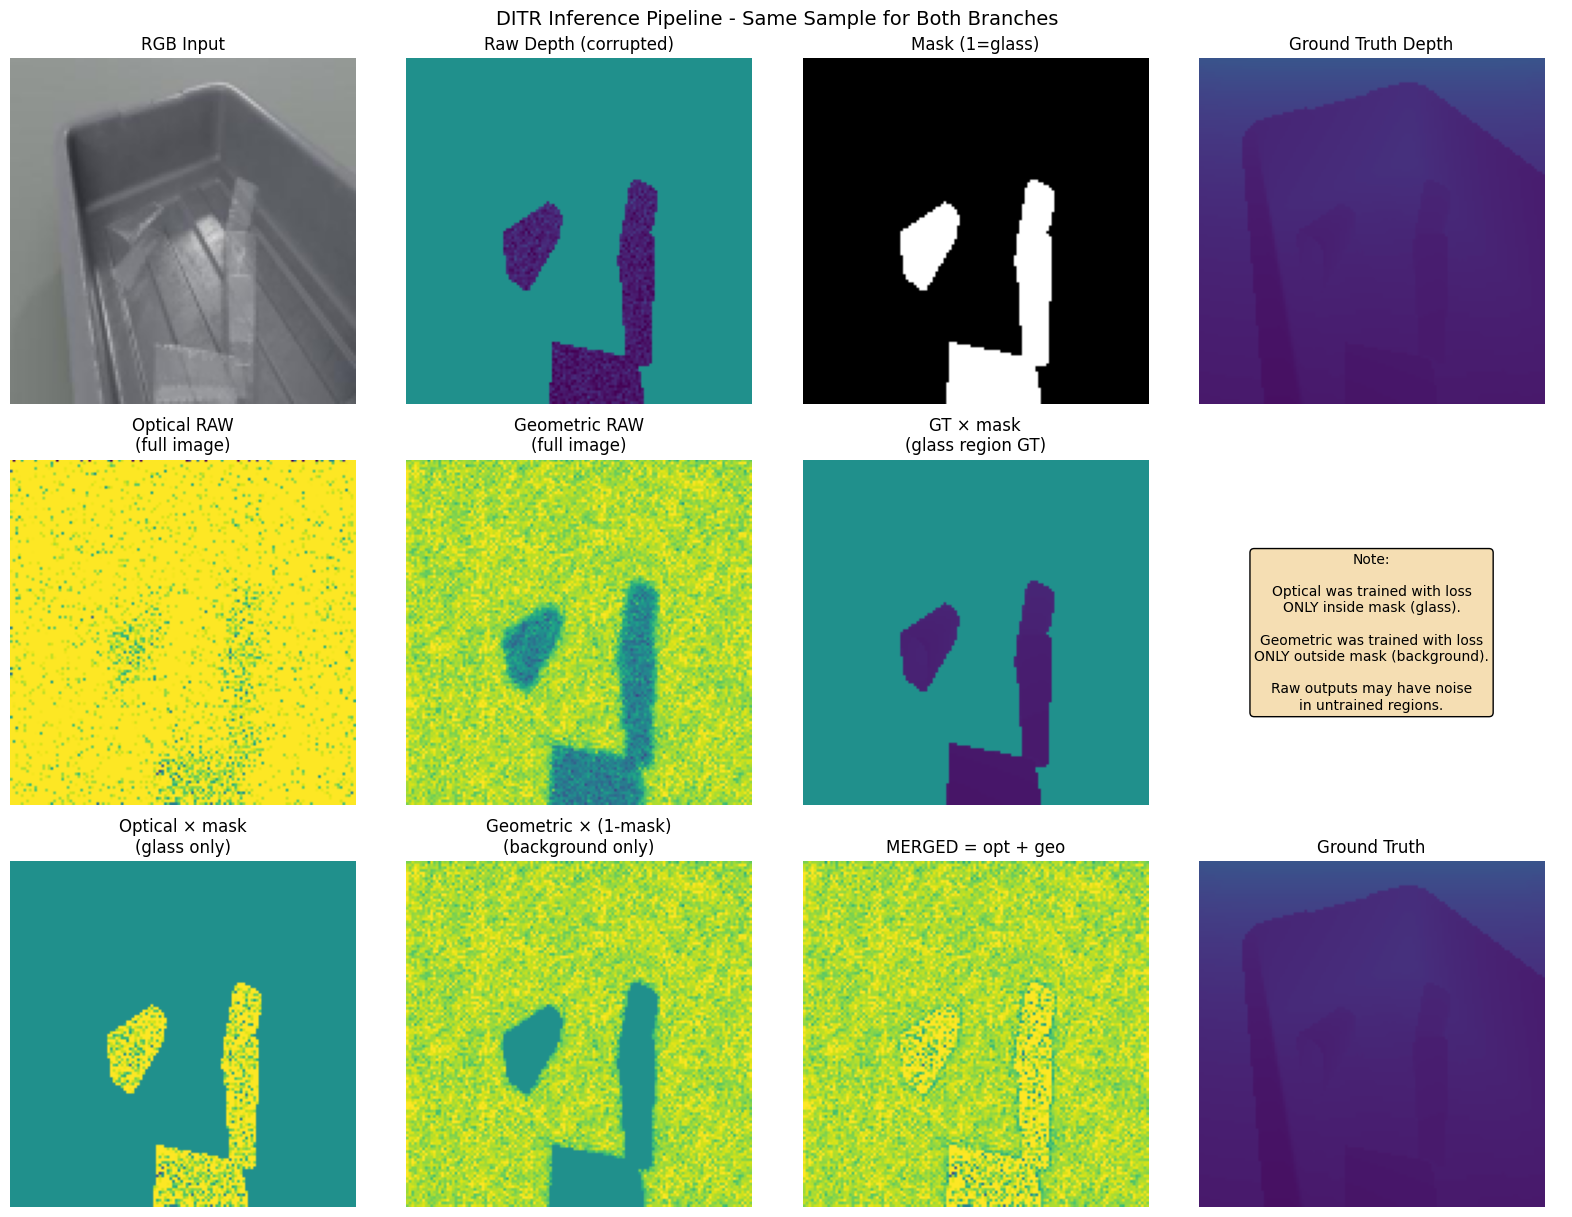

In [7]:
def run_ditr_inference_with_viz(opt_diff, geo_diff, batch, device):
    """
    DITR inference following the pipeline using the SAME sample for both branches:
    - Track A (Optical): generates inside mask (transparent area)
    - Track B (Geometric): generates outside mask (background)
    - Merge: pred_opt * mask + pred_geo * (1 - mask)
    """
    opt_diff.model.eval()
    geo_diff.model.eval()

    # --- Prepare Data (SAME sample for both branches) ---
    cond = batch["conditioning"].to(device)

    # The optical mask: 1 = transparent/glass area
    mask = batch["loss_mask"].to(device)

    # Ground truth depth
    gt_depth = batch["pixel_values"].to(device)

    # Extract RGB and raw depth from conditioning for visualization
    # cond layout: [RGB(3), raw(1), guide(1)]
    rgb = cond[:, :3, :, :]
    raw_depth = cond[:, 3:4, :, :]

    # Shape for sampling
    b, _, h, w = cond.shape
    shape = (b, 1, h, w)

    print("Running Optical Branch (unconstrained sampling)...")
    # Get RAW output from optical model (full image)
    pred_opt_raw = opt_diff.sample(cond=cond, shape=shape, device=device)

    print("Running Geometric Branch (unconstrained sampling)...")
    # Get RAW output from geometric model (full image)
    pred_geo_raw = geo_diff.sample(cond=cond, shape=shape, device=device)

    # --- Merge according to DITR pipeline ---
    # Optical output is valid INSIDE mask (glass area)
    # Geometric output is valid OUTSIDE mask (background)
    clean_opt = pred_opt_raw * mask           # Keep only glass region from optical
    clean_geo = pred_geo_raw * (1.0 - mask)   # Keep only background from geometric

    # Element-wise add (disjoint regions, no overlap)
    final_depth = clean_opt + clean_geo

    return {
        "pred_opt_raw": pred_opt_raw,      # Raw optical output (full image)
        "pred_geo_raw": pred_geo_raw,      # Raw geometric output (full image)
        "clean_opt": clean_opt,            # Optical masked (only glass region)
        "clean_geo": clean_geo,            # Geometric masked (only background)
        "merged": final_depth,             # Final merged output
        "mask": mask,                      # The mask (1=glass)
        "gt_depth": gt_depth,              # Ground truth depth
        "rgb": rgb,                        # RGB input
        "raw_depth": raw_depth,            # Raw/corrupted input depth
    }


# --- Visualization ---
def viz_all_results(results):
    """Visualize raw outputs, masked outputs, and final merge."""
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    def show(ax, tensor, title, cmap='viridis', vmin=-1, vmax=1):
        img = tensor[0, 0].cpu().numpy()
        im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')
        return im

    def show_rgb(ax, tensor, title):
        img = tensor[0].cpu().numpy().transpose(1, 2, 0)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    # Row 1: Input data
    show_rgb(axes[0, 0], results["rgb"], "RGB Input")
    show(axes[0, 1], results["raw_depth"], "Raw Depth (corrupted)")
    show(axes[0, 2], results["mask"], "Mask (1=glass)", cmap='gray', vmin=0, vmax=1)
    show(axes[0, 3], results["gt_depth"], "Ground Truth Depth")

    # Row 2: Raw model outputs (before masking)
    show(axes[1, 0], results["pred_opt_raw"], "Optical RAW\n(full image)")
    show(axes[1, 1], results["pred_geo_raw"], "Geometric RAW\n(full image)")
    # Show what optical generates INSIDE the mask vs GT
    gt_masked = results["gt_depth"] * results["mask"]
    show(axes[1, 2], gt_masked, "GT × mask\n(glass region GT)")
    axes[1, 3].axis('off')
    axes[1, 3].text(0.5, 0.5,
        "Note:\n\n"
        "Optical was trained with loss\n"
        "ONLY inside mask (glass).\n\n"
        "Geometric was trained with loss\n"
        "ONLY outside mask (background).\n\n"
        "Raw outputs may have noise\n"
        "in untrained regions.",
        ha='center', va='center', fontsize=10,
        transform=axes[1, 3].transAxes, bbox=dict(boxstyle='round', facecolor='wheat'))

    # Row 3: Masked outputs and merge
    show(axes[2, 0], results["clean_opt"], "Optical × mask\n(glass only)")
    show(axes[2, 1], results["clean_geo"], "Geometric × (1-mask)\n(background only)")
    show(axes[2, 2], results["merged"], "MERGED = opt + geo")
    show(axes[2, 3], results["gt_depth"], "Ground Truth")

    plt.tight_layout()
    plt.suptitle("DITR Inference Pipeline - Same Sample for Both Branches", y=1.01, fontsize=14)
    plt.show()


# Run inference with the SAME sample
with torch.no_grad():
    results = run_ditr_inference_with_viz(opt_diff, geo_diff, batch_shared, device)
    viz_all_results(results)